# Multilingual Health QA — EDA, Preprocessing & Experiment 1

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

**Self-contained.** Upload `Train.csv`, `Val.csv`, `Test.csv`, `SampleSubmission.csv`
and Run All. No repo clone required. This notebook covers:

1. Setup & data loading
2. Exploratory Data Analysis (with the insights that drive every later decision)
3. Leakage-safe, subset-stratified preprocessing
4. The official evaluation metric (whitespace ROUGE) + test-reweighted aggregation
5. **Experiment 1** — TF-IDF retrieval baseline (the floor every model must beat)

A placeholder section at the end shows where Experiment 2+ (fine-tuning) plugs in,
so this becomes your single master notebook.

## 1. Setup

In [ ]:
!pip install -q scikit-learn pandas numpy matplotlib rouge-score pyarrow

  Preparing metadata (setup.py) ... done


In [ ]:
import os, re, json, random, unicodedata
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")  # reduce fragmentation
from collections import Counter
from dataclasses import dataclass, asdict, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Reproducibility: one global seed everywhere (Zindi requires re-runs to match)
SEED = 42
def set_global_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    except ImportError:
        pass
set_global_seed()

plt.rcParams.update({"figure.dpi":110, "font.size":10, "axes.spines.top":False,
                     "axes.spines.right":False, "axes.grid":True, "grid.alpha":0.25})
PALETTE = plt.get_cmap("tab10").colors
pd.set_option("display.max_colwidth", 100)
print("Setup complete.")

Setup complete.


In [ ]:
# Column names + dataset constants
ID_COL, INPUT_COL, OUTPUT_COL, SUBSET_COL = "ID", "input", "output", "subset"

LANG_NAME    = {"Aka":"Akan","Amh":"Amharic","Eng":"English","Lug":"Luganda","Swa":"Swahili"}
COUNTRY_NAME = {"Gha":"Ghana","Eth":"Ethiopia","Ken":"Kenya","Uga":"Uganda"}
SUBMISSION_COLS = ["ID","TargetRLF1","TargetR1F1","TargetLLM"]
METRIC_WEIGHTS  = {"rouge1_f1":0.37, "rougeL_f1":0.37, "llm_judge":0.26}

INSTRUCTION_SUFFIXES = ["please answer in detail.",
                        "please answer this using simple medical terms."]
ANSWER_METADATA_PREFIX_RE = r'^\s*this is a question about[,:]\s*[^.]*\.\s*'
print("Constants set.")

Constants set.


## 2. Load the data

On Colab, upload the four CSVs (Files panel or the upload cell below). The
resolver checks a few common locations so the same notebook runs locally too.

In [ ]:
def find_csv(*names):
    """Return the first existing path among common Colab/local locations."""
    roots = [".", "data", "/content", "/content/data", os.environ.get("DATA_DIR","")]
    for n in names:
        for r in roots:
            p = os.path.join(r, n) if r else n
            if os.path.exists(p):
                return p
    raise FileNotFoundError(f"Could not find any of {names}. Upload the CSVs.")

# In Colab you can instead run:
# from google.colab import files; files.upload()

TRAIN_PATH  = find_csv("Train.csv", "Train__2_.csv")
VAL_PATH    = find_csv("Val.csv")
TEST_PATH   = find_csv("Test.csv", "Test__2_.csv")
SAMPLE_PATH = find_csv("SampleSubmission.csv")

train_raw = pd.read_csv(TRAIN_PATH)
val       = pd.read_csv(VAL_PATH)
test      = pd.read_csv(TEST_PATH)
sample    = pd.read_csv(SAMPLE_PATH)
print("train:", train_raw.shape, "| val:", val.shape,
      "| test:", test.shape, "| sample:", sample.shape)
train_raw.head(3)

train: (29815, 4) | val: (6686, 4) | test: (2618, 3) | sample: (2618, 4)


,ID,input,output,subset
0,ID_TR_Aka_Gha_A3B1799D,Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi n...,Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam m...,Aka_Gha
1,ID_TR_Aka_Gha_1C80317F,"Edinnsiananmu bɛn na nnipa a ɛsono wɔn bɔbeasu taa de di dwuma, na yɛbɛyɛ dɛn ahwɛ ahu sɛ yɛde r...","Wɔ Ghana mu no, amanmmra no gye binary gender nkutoo tom a she/he edinnsiananmu nkutoo na ɛka ho",Aka_Gha
2,ID_TR_Aka_Gha_06671AD1,Ɔkwan bɛn so na ɔbarima ne ɔbea nna a wɔtwe wɔn ho fi ho anaa nna mu adwumadi a wɔtwentwɛn so no...,"Sɛ wɔtwe wɔn ho fi nna mu anaasɛ wɔtwentwɛn wɔn nan ase a, ɛboa ma asiane nso tew denam asiane a...",Aka_Gha


## 3. Exploratory Data Analysis

The four findings below drive every later modelling decision, so we surface them
explicitly rather than just plotting.

In [ ]:
# Light helpers used throughout
WS_RE = re.compile(r"\s+")
def normalize_whitespace(t):
    # NFC Unicode normalisation (defensive: idempotent on this data, but
    # guarantees a single canonical form for Ethiopic/Akan diacritics) + collapse WS.
    if not isinstance(t, str):
        return ""
    return WS_RE.sub(" ", unicodedata.normalize("NFC", t)).strip()

# Parse the instruction suffix into a style tag (feature, not noise)
_SUFFIX_RES = [(s, re.compile(r",\s*"+re.escape(s)+r"\s*$", re.I)) for s in INSTRUCTION_SUFFIXES]
def extract_instruction_style(q):
    for suf, rgx in _SUFFIX_RES:
        if rgx.search(q):
            core = rgx.sub("", q).strip().rstrip(",").strip()
            return core, ("detailed" if "detail" in suf else "simple")
    return q, "none"

_TOPIC_RE = re.compile(r"^\s*this is a question about[,:]\s*([^.]*)\.", re.I)
def extract_topic(a):
    m = _TOPIC_RE.match(a or ""); return m.group(1).strip() if m else ""

# Build EDA feature columns on a copy (does NOT alter training data)
eda = train_raw.copy()
eda[INPUT_COL]  = eda[INPUT_COL].map(normalize_whitespace)
eda[OUTPUT_COL] = eda[OUTPUT_COL].map(normalize_whitespace)
eda["style_tag"] = eda[INPUT_COL].map(lambda q: extract_instruction_style(q)[1])
eda["topic"]     = eda[OUTPUT_COL].map(extract_topic)
eda["in_words"]  = eda[INPUT_COL].str.split().map(len)
eda["out_words"] = eda[OUTPUT_COL].str.split().map(len)
print("EDA frame ready:", eda.shape)

EDA frame ready: (29815, 8)


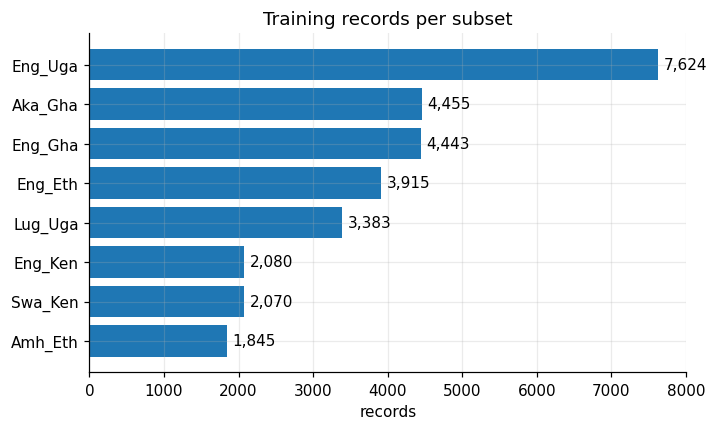

In [ ]:
# --- Figure 1: records per subset
counts = eda[SUBSET_COL].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(7,4))
ax.barh(counts.index, counts.values, color=PALETTE[0])
for i,v in enumerate(counts.values): ax.text(v+max(counts)*0.01, i, f"{v:,}", va="center")
ax.set_xlabel("records"); ax.set_title("Training records per subset"); plt.show()

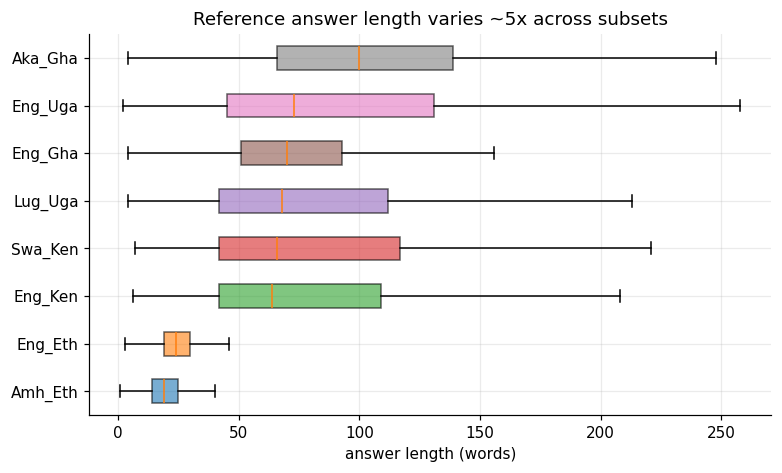

subset
Aka_Gha    100.0
Eng_Uga     73.0
Eng_Gha     70.0
Lug_Uga     68.0
Swa_Ken     66.0
Eng_Ken     64.0
Eng_Eth     24.0
Amh_Eth     19.0
Name: out_words, dtype: float64


In [ ]:
# --- Figure 2: answer length varies ~5x across subsets (the key lever)
order = eda.groupby(SUBSET_COL)["out_words"].median().sort_values().index
data  = [eda.loc[eda[SUBSET_COL]==s,"out_words"].values for s in order]
fig, ax = plt.subplots(figsize=(8,4.5))
bp = ax.boxplot(data, vert=False, showfliers=False, patch_artist=True)
ax.set_yticks(range(1,len(order)+1)); ax.set_yticklabels(list(order))
for p,c in zip(bp["boxes"], PALETTE): p.set_facecolor(c); p.set_alpha(0.6)
ax.set_xlabel("answer length (words)")
ax.set_title("Reference answer length varies ~5x across subsets"); plt.show()

print(eda.groupby(SUBSET_COL)["out_words"].median().round(1).sort_values(ascending=False))

In [ ]:
# --- Duplication & leakage diagnostics
def q_key(s): return normalize_whitespace(s).lower()
keys = eda[INPUT_COL].map(q_key)
vc = keys.value_counts(); repeated = vc[vc>1]
diff_ans = eda.assign(_k=keys).groupby("_k")[OUTPUT_COL].nunique()
cross    = eda.assign(_k=keys).groupby("_k")[SUBSET_COL].nunique()
print(f"distinct questions            : {keys.nunique():,}")
print(f"repeated questions            : {len(repeated):,} (covering {repeated.sum():,} rows)")
print(f"  ...with differing answers   : {(diff_ans>1).sum():,}")
print(f"  ...spanning >1 subset       : {(cross>1).sum():,}")
print(f"exact duplicate (q,a) pairs   : {eda.duplicated(subset=[INPUT_COL,OUTPUT_COL]).sum():,}")
print(f"blank inputs                  : {(eda[INPUT_COL].str.len()==0).sum():,}")
print("\nstyle tags:", eda['style_tag'].value_counts().to_dict())

distinct questions            : 28,215
repeated questions            : 1,570 (covering 3,170 rows)
  ...with differing answers   : 1,256
  ...spanning >1 subset       : 508
exact duplicate (q,a) pairs   : 287
blank inputs                  : 1

style tags: {'none': 26515, 'simple': 1653, 'detailed': 1647}


### EDA takeaways (these justify the design that follows)

1. **Answer length varies ~5x by subset** (Amharic/Eng-Ethiopia ~20 words, Akan ~106).
   Over-generating tanks ROUGE precision, so generation length must be calibrated
   per subset — the single highest-ROI inference lever.
2. **~1,570 questions repeat** (≈3,170 rows), many with differing answers and some
   across subsets → a naive random split leaks. We split by *question group*.
3. **Instruction suffixes** ("please answer in detail" / "...simple medical terms")
   are parsed into a `style_tag` feature, not discarded.
4. **Test mix ≠ Val mix**: the test set is ~80% the long-answer subsets and only
   ~4.6% the short Ethiopia subsets (vs ~15% in Val). The **Ghana subsets
   (Akan + Eng-Ghana = 37.6% of test) are where the leaderboard is won.**

## 3B. Multilingual text handling & deeper EDA

For a multilingual challenge the language properties of the text drive real
modelling decisions, so we examine scripts, code-mixing, normalisation and the
cross-split distribution explicitly — not just row counts.

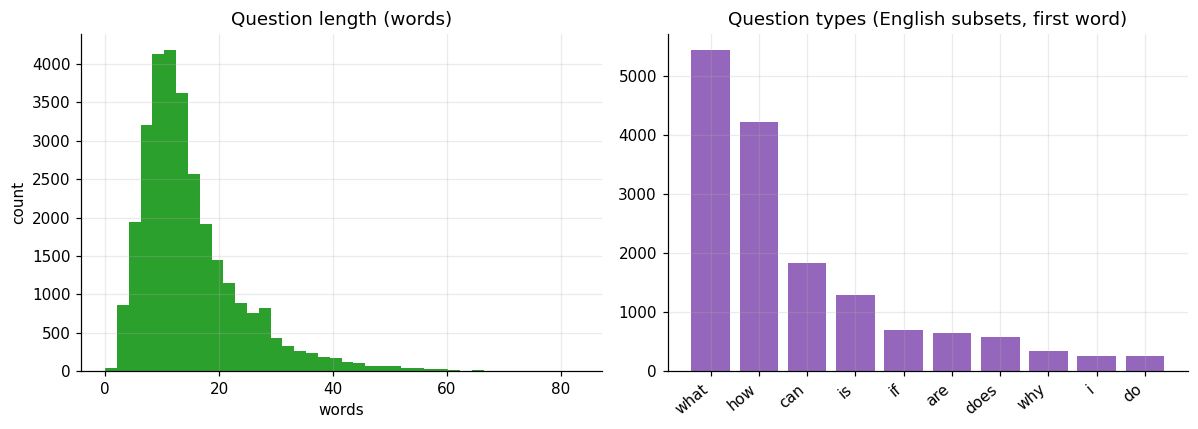

In [ ]:
# Deeper EDA: question length + question-type mix (English subsets)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(eda["in_words"], bins=40, color=PALETTE[2])
ax[0].set_title("Question length (words)"); ax[0].set_xlabel("words"); ax[0].set_ylabel("count")
eng = eda[eda[SUBSET_COL].str.startswith("Eng")]
starters = Counter(q.split()[0].lower().strip("?,.") for q in eng[INPUT_COL] if q.split())
top = dict(sorted(starters.items(), key=lambda x: -x[1])[:10])
ax[1].bar(list(top), list(top.values()), color=PALETTE[4])
ax[1].set_title("Question types (English subsets, first word)")
plt.setp(ax[1].get_xticklabels(), rotation=40, ha="right")
plt.tight_layout(); plt.show()

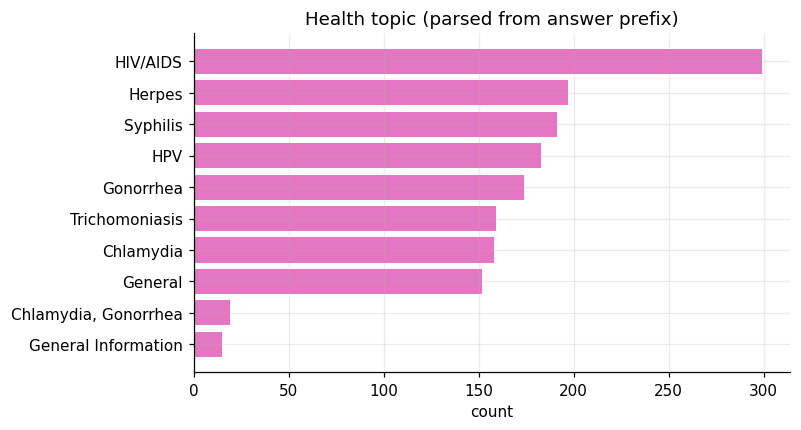

answers carrying an explicit topic prefix: 2215


In [ ]:
# Health-topic distribution (parsed from the answer-prefix artifact)
topics = eda.loc[eda["topic"] != "", "topic"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(topics.index[::-1], topics.values[::-1], color=PALETTE[6])
ax.set_title("Health topic (parsed from answer prefix)"); ax.set_xlabel("count"); plt.show()
print("answers carrying an explicit topic prefix:", int((eda['topic'] != '').sum()))

Script composition (% of letters):
         Latin  Other (diacritics)  Ethiopic
subset                                      
Aka_Gha   90.7                 9.3       0.0
Amh_Eth    2.2                 0.0      97.8
Eng_Eth  100.0                 0.0       0.0
Eng_Gha  100.0                 0.0       0.0
Eng_Ken  100.0                 0.0       0.0
Eng_Uga  100.0                 0.0       0.0
Lug_Uga  100.0                 0.0       0.0
Swa_Ken  100.0                 0.0       0.0


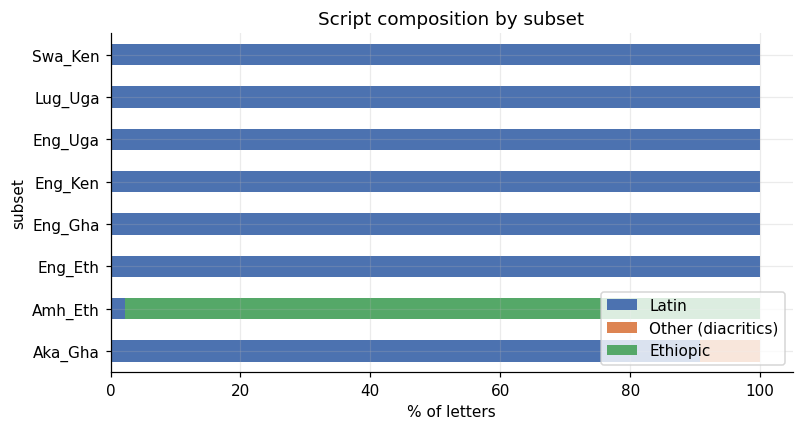

In [ ]:
# --- Script composition per subset (sampled for speed) ---
def script_counts(text):
    c = Counter()
    for ch in str(text):
        if not ch.isalpha(): continue
        o = ord(ch)
        if   0x1200 <= o <= 0x137F: c["Ethiopic"] += 1
        elif o < 0x250:             c["Latin"] += 1
        else:                       c["Other (diacritics)"] += 1
    return c

rows = []
for s in sorted(eda[SUBSET_COL].unique()):
    sub = eda[eda[SUBSET_COL] == s].head(500)
    tot = Counter()
    for t in pd.concat([sub[INPUT_COL], sub[OUTPUT_COL]]): tot += script_counts(t)
    n = sum(tot.values()) or 1
    rows.append({"subset": s, **{k: round(v/n*100, 1) for k, v in tot.items()}})
script_df = pd.DataFrame(rows).set_index("subset").fillna(0)
print("Script composition (% of letters):"); print(script_df)
script_df.plot(kind="barh", stacked=True, figsize=(8, 4),
               color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Script composition by subset"); plt.xlabel("% of letters")
plt.legend(loc="lower right"); plt.show()

Akan answers: mean share of pure-English tokens = 0.59
Akan answers that are >40% English tokens     = 98%


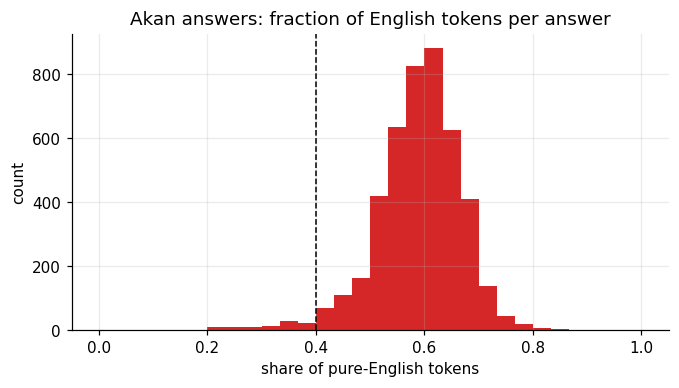

In [ ]:
# --- Code-mixing: the Akan 'answers' are heavily Akan-English mixed ---
def english_share(t):
    toks = str(t).split()
    return sum(1 for w in toks if re.fullmatch(r"[A-Za-z]+", w)) / len(toks) if toks else 0.0
aka_sh = eda.loc[eda[SUBSET_COL] == "Aka_Gha", OUTPUT_COL].map(english_share)
print(f"Akan answers: mean share of pure-English tokens = {aka_sh.mean():.2f}")
print(f"Akan answers that are >40% English tokens     = {(aka_sh > 0.4).mean()*100:.0f}%")
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(aka_sh, bins=30, color=PALETTE[3]); ax.axvline(0.4, color="k", ls="--", lw=1)
ax.set_title("Akan answers: fraction of English tokens per answer")
ax.set_xlabel("share of pure-English tokens"); ax.set_ylabel("count"); plt.show()

In [ ]:
# One sample Q/A per subset — see the multilingual text directly
for s in sorted(eda[SUBSET_COL].unique()):
    r = eda[eda[SUBSET_COL] == s].iloc[0]
    print(f"[{s}]  Q: {r[INPUT_COL][:90]}")
    print(f"          A: {r[OUTPUT_COL][:120]}\n")

[Aka_Gha]  Q: Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Ye
          A: Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na wɔagy

[Amh_Eth]  Q: የረጅም ጊዜ ጤናን በተመለከተ በጣም ሊያሳስበኝ የሚገቡ ሶስት ዋና ዋና ኢንፌክሽኖች የትኞቹ ናቸው?
          A: ኤች አይ ቪ፣ ሄፓታይተስ ቢ እና ሂውማን ፓፒሎማ ቫይረስ (HPV)ናቸው።

[Eng_Eth]  Q: How is syphilis diagnosed?
          A: Blood tests like VDRL and RPR confirm syphilis infection.

[Eng_Gha]  Q: What should I do if I have unprotected sex or experience a contraceptive failure?
          A: If you have unprotected sex or experience contraceptive failure, consider the following steps: - Take emergency contrace

[Eng_Ken]  Q: How can society ensure that HIV patients are incorporated in it?
          A: Incorporating HIV patients into society is essential to reduce stigma, promote inclusivity, and support their overall we

[Eng_Uga]  Q: What is HIV and TB co-infection?
          A: This 

In [ ]:
# Documented Unicode-normalisation check (is it needed?)
def n_changed(series, form):
    s = series.astype(str)
    return int((s != s.map(lambda x: unicodedata.normalize(form, x))).sum())
for form in ["NFC", "NFKC"]:
    print(f"{form}: inputs changed={n_changed(train_raw[INPUT_COL], form)}, "
          f"outputs changed={n_changed(train_raw[OUTPUT_COL], form)}")
print("\nDecision: data is already NFC-clean (0 changes); we apply NFC defensively")
print("(idempotent, reproducible). NFKC is NOT applied — it would rewrite 97 answers'")
print("compatibility characters and risk meaning drift.")

NFC: inputs changed=0, outputs changed=0
NFKC: inputs changed=0, outputs changed=97

Decision: data is already NFC-clean (0 changes); we apply NFC defensively
(idempotent, reproducible). NFKC is NOT applied — it would rewrite 97 answers'
compatibility characters and risk meaning drift.


         train_%  val_%  test_%
subset                         
Eng_Uga     25.6   25.2    28.4
Aka_Gha     14.9   16.7    18.8
Eng_Gha     14.9   16.5    18.8
Lug_Uga     11.3   12.7    14.3
Swa_Ken      6.9    7.7     8.7
Eng_Ken      7.0    5.8     6.4
Eng_Eth     13.1    8.4     2.3
Amh_Eth      6.2    6.9     2.3


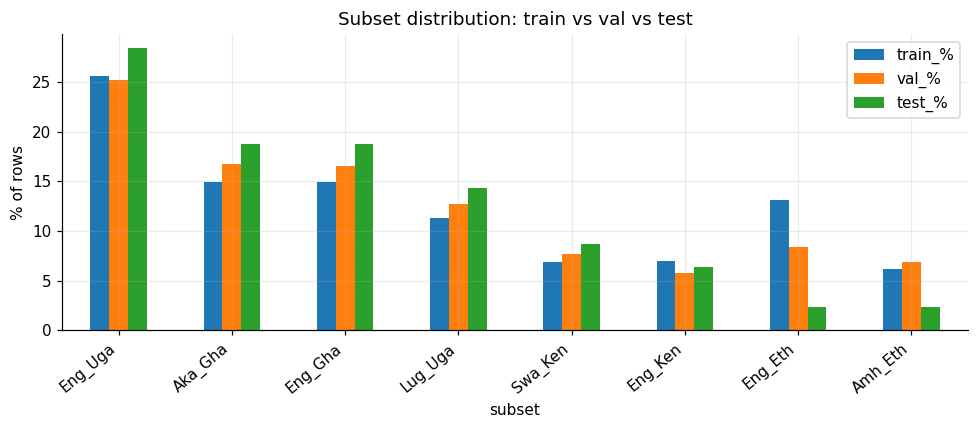

In [ ]:
# Subset distribution across splits -> quantifies the Val-vs-Test skew
prop = pd.DataFrame({
    "train_%": (train_raw[SUBSET_COL].value_counts(normalize=True)*100).round(1),
    "val_%":   (val[SUBSET_COL].value_counts(normalize=True)*100).round(1),
    "test_%":  (test[SUBSET_COL].value_counts(normalize=True)*100).round(1),
}).fillna(0).sort_values("test_%", ascending=False)
print(prop)
prop.plot(kind="bar", figsize=(9, 4)); plt.title("Subset distribution: train vs val vs test")
plt.ylabel("% of rows"); plt.xticks(rotation=40, ha="right"); plt.tight_layout(); plt.show()

### Multilingual handling — takeaways

- **Akan is code-mixed, not monolingual:** ~59% of tokens in Aka_Gha answers are
  English and 98% of Akan answers are >40% English. This explains the weak Akan
  retrieval score and implies an Akan-only tokenizer helps less than expected — a
  broadly multilingual model that also handles English is preferable.
- **Two scripts, both scored correctly:** Amharic is ~98% Ethiopic; Akan carries
  ɛ/ɔ diacritics (~9% non-ASCII). The official whitespace ROUGE handles both
  (verified earlier), so no transliteration/romanisation is needed.
- **Unicode:** the data is already NFC-clean; we apply NFC defensively and avoid
  NFKC (it would rewrite 97 answers).
- **Split skew quantified:** Val over-represents the short Ethiopia subsets vs
  Test — the reason experiments are scored with a test-reweighted aggregate, not
  a raw row-mean.

## 4. Preprocessing — leakage-safe & subset-stratified

Cleaning is **opt-in** because ~74% of the score is lexical overlap with the
reference answers: cleaning that moves targets away from the reference style can
*lower* the score. Defaults below preserve it.

In [ ]:
@dataclass
class CleanConfig:
    normalize_ws: bool = True
    drop_blank: bool = True
    drop_exact_duplicates: bool = True
    strip_answer_prefix: bool = False        # target-altering -> off by default (A/B it)
    strip_instruction_suffix: bool = False   # target-altering -> off by default (A/B it)
    min_output_chars: int = 1

def strip_answer_metadata_prefix(a):
    return re.sub(ANSWER_METADATA_PREFIX_RE, "", a or "", flags=re.I).strip()

def clean_dataframe(df, cfg=CleanConfig()):
    out = df.copy()
    if cfg.normalize_ws:
        out[INPUT_COL]  = out[INPUT_COL].map(normalize_whitespace)
        out[OUTPUT_COL] = out[OUTPUT_COL].map(normalize_whitespace)
    if cfg.drop_blank:
        b=len(out)
        out = out[(out[INPUT_COL].str.len()>0)&(out[OUTPUT_COL].str.len()>=cfg.min_output_chars)].copy()
        if len(out)!=b: print(f"  drop_blank: {b:,} -> {len(out):,}")
    parsed = out[INPUT_COL].map(extract_instruction_style)
    out["core_question"] = parsed.map(lambda t:t[0])
    out["style_tag"]     = parsed.map(lambda t:t[1])
    out["topic"]         = out[OUTPUT_COL].map(extract_topic)
    if cfg.strip_instruction_suffix: out[INPUT_COL]=out["core_question"]
    if cfg.strip_answer_prefix:      out[OUTPUT_COL]=out[OUTPUT_COL].map(strip_answer_metadata_prefix)
    if cfg.drop_exact_duplicates:
        b=len(out); out=out.drop_duplicates(subset=[INPUT_COL,OUTPUT_COL]).copy()
        if len(out)!=b: print(f"  drop_exact_duplicates: {b:,} -> {len(out):,}")
    out["q_key"]    = out[INPUT_COL].map(q_key)
    out["out_words"]= out[OUTPUT_COL].str.split().map(len)
    return out.reset_index(drop=True)

train = clean_dataframe(train_raw, CleanConfig())
print("clean train:", train.shape)

  drop_blank: 29,815 -> 29,814
  drop_exact_duplicates: 29,814 -> 29,527
clean train: (29527, 9)


In [ ]:
# Leakage-safe, subset-stratified split (StratifiedGroupKFold)
from sklearn.model_selection import StratifiedGroupKFold

def stratified_group_split(df, val_size=0.10, seed=SEED):
    n_splits = max(2, round(1/val_size))
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    tr_idx, va_idx = next(sgkf.split(df, df[SUBSET_COL].values, df["q_key"].values))
    tr, va = df.iloc[tr_idx].reset_index(drop=True), df.iloc[va_idx].reset_index(drop=True)
    assert not (set(tr["q_key"]) & set(va["q_key"])), "leakage!"
    return tr, va

train_split, val_split = stratified_group_split(train, val_size=0.10, seed=SEED)
print(f"internal split -> train {len(train_split):,} | val {len(val_split):,}")
print("question-group overlap:", len(set(train_split['q_key']) & set(val_split['q_key'])), "(must be 0)")
print("\nsubset proportions (train% vs val%):")
print(pd.DataFrame({
    "train_%": (train_split[SUBSET_COL].value_counts(normalize=True)*100).round(1),
    "val_%":   (val_split[SUBSET_COL].value_counts(normalize=True)*100).round(1),
}).sort_index())

internal split -> train 26,580 | val 2,947
question-group overlap: 0 (must be 0)

subset proportions (train% vs val%):
         train_%  val_%
subset                 
Aka_Gha     15.1   15.0
Amh_Eth      6.2    6.2
Eng_Eth     13.3   12.9
Eng_Gha     15.0   15.6
Eng_Ken      7.1    6.6
Eng_Uga     24.9   24.5
Lug_Uga     11.4   12.0
Swa_Ken      7.0    7.1


> We hold out our own internal split from Train for fast iteration, **and** keep
> the provided **Val.csv (6,686 labelled rows)** as a faithful local test bench.
> Experiment scoring below uses Val.csv.

## 5. Evaluation — the OFFICIAL metric

The leaderboard scores ROUGE with a **whitespace tokenizer, no stemmer, no
lowercasing** (from the competition starter notebook) — safe for African scripts
(Amharic is scored normally). We also report a **test-proportion-reweighted**
aggregate, because Val over-represents the easy Ethiopia subsets vs Test.

In [ ]:
from rouge_score import rouge_scorer
from rouge_score.tokenizers import Tokenizer

class WhitespaceTokenizer(Tokenizer):
    """Official leaderboard tokenizer: split on whitespace, no stemming/lowercasing."""
    def tokenize(self, text):
        return [] if text is None else str(text).strip().split()

def make_scorer():
    return rouge_scorer.RougeScorer(["rouge1","rougeL"], use_stemmer=False,
                                    tokenizer=WhitespaceTokenizer())

# Test-set subset proportions (from Test.csv) -> reweight Val to estimate leaderboard
TEST_COUNTS = test[SUBSET_COL].value_counts().to_dict()
_tot = sum(TEST_COUNTS.values())
TEST_WEIGHTS = {k: v/_tot for k,v in TEST_COUNTS.items()}

def rouge_weighted(r1, rL):  # ROUGE-only proxy (LLM-judge not reproducible offline)
    w = METRIC_WEIGHTS; return (w["rouge1_f1"]*r1 + w["rougeL_f1"]*rL)/(w["rouge1_f1"]+w["rougeL_f1"])

def evaluate(predictions, references, subsets):
    scorer = make_scorer(); r1=[]; rL=[]
    for p,r in zip(predictions, references):
        s = scorer.score(str(r), str(p))
        r1.append(s["rouge1"].fmeasure); rL.append(s["rougeL"].fmeasure)
    per = pd.DataFrame({"subset":list(subsets),"rouge1_f1":r1,"rougeL_f1":rL})
    by_subset = (per.groupby("subset")[["rouge1_f1","rougeL_f1"]].mean()
                   .assign(n=per.groupby("subset").size()).round(4))
    m1,mL = per["rouge1_f1"].mean(), per["rougeL_f1"].mean()
    # test-reweighted
    rw1=rwL=cov=0.0
    for s,w in TEST_WEIGHTS.items():
        if s in by_subset.index:
            rw1+=w*by_subset.loc[s,"rouge1_f1"]; rwL+=w*by_subset.loc[s,"rougeL_f1"]; cov+=w
    rw1, rwL = rw1/cov, rwL/cov
    return {
        "by_subset": by_subset,
        "row_mean":  {"rouge1_f1":m1,"rougeL_f1":mL,"rouge_weighted":rouge_weighted(m1,mL)},
        "reweighted":{"rouge1_f1":rw1,"rougeL_f1":rwL,"rouge_weighted":rouge_weighted(rw1,rwL)},
    }

def show_eval(res, title=""):
    print(f"== {title} =="); print(res["by_subset"])
    m,r = res["row_mean"], res["reweighted"]
    print(f"\nrow-mean       : R1={m['rouge1_f1']:.4f} RL={m['rougeL_f1']:.4f} weighted={m['rouge_weighted']:.4f}")
    print(f"test-reweighted: R1={r['rouge1_f1']:.4f} RL={r['rougeL_f1']:.4f} weighted={r['rouge_weighted']:.4f}  <- leaderboard estimate")
print("Evaluator ready.")

Evaluator ready.


In [ ]:
# Tiny experiment tracker -> progression table builds itself
EXPERIMENTS = []
def log_experiment(exp_id, description, res, hypothesis="", notes=""):
    r = res["reweighted"]
    EXPERIMENTS.append({"exp_id":exp_id, "description":description,
        "lb_rouge1_f1":round(r["rouge1_f1"],4), "lb_rougeL_f1":round(r["rougeL_f1"],4),
        "lb_rouge_weighted":round(r["rouge_weighted"],4),
        "hypothesis":hypothesis, "notes":notes})
    df = pd.DataFrame(EXPERIMENTS)
    df["delta"] = df["lb_rouge_weighted"].diff().round(4)
    return df

## 6. Experiment 1 — TF-IDF Retrieval Baseline (the floor)

**Hypothesis:** because ~1,570 questions repeat and 74% of the score is lexical
overlap, copying the answer of the most similar *training* question (within the
same subset) is a strong, fully reproducible floor. Any fine-tuned model must beat it.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

def retrieval_baseline(train_df, query_df, per_subset=True):
    set_global_seed()
    out = query_df.copy().reset_index(drop=True)
    out["prediction"]=""; out["match_score"]=np.nan
    groups = list(out.groupby(SUBSET_COL).groups.items()) if per_subset else [("all", out.index)]
    for subset, idx in groups:
        q_idx = list(idx)
        tr = train_df[train_df[SUBSET_COL]==subset] if per_subset else train_df
        if len(tr)==0: continue
        vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(2,5), min_df=1, lowercase=False)
        M = vec.fit_transform(tr[INPUT_COL].astype(str).tolist())
        ans = tr[OUTPUT_COL].astype(str).tolist()
        Q = vec.transform(out.loc[q_idx, INPUT_COL].astype(str).tolist())
        sims = linear_kernel(Q, M); best = sims.argmax(axis=1)
        out.loc[q_idx,"prediction"]  = [ans[b] for b in best]
        out.loc[q_idx,"match_score"] = sims[np.arange(sims.shape[0]), best]
    return out

set_global_seed()
pred1 = retrieval_baseline(train, val, per_subset=True)   # corpus = full clean train
print("median match similarity:", round(pred1['match_score'].median(),3))
res1 = evaluate(pred1["prediction"], val[OUTPUT_COL], val[SUBSET_COL])
show_eval(res1, "Experiment 1 — Retrieval baseline (official metric, on Val)")

median match similarity: 0.572
== Experiment 1 — Retrieval baseline (official metric, on Val) ==
         rouge1_f1  rougeL_f1     n
subset                             
Aka_Gha     0.2868     0.1691  1114
Amh_Eth     0.1502     0.1401   462
Eng_Eth     0.5260     0.5074   564
Eng_Gha     0.2589     0.1707  1104
Eng_Ken     0.6130     0.5761   390
Eng_Uga     0.5168     0.4715  1688
Lug_Uga     0.5185     0.4971   846
Swa_Ken     0.6119     0.5768   518

row-mean       : R1=0.4245 RL=0.3691 weighted=0.3968
test-reweighted: R1=0.4316 RL=0.3709 weighted=0.4012  <- leaderboard estimate


In [ ]:
# Log it -> progression table
log_experiment("01_retrieval_baseline",
    "TF-IDF char_wb(2,5) nearest-train-question copy, per-subset", res1,
    hypothesis="Repeated questions + 74% lexical metric => copied answers are a strong floor.",
    notes="Battleground = Ghana subsets (low score + 37.6% of test).")

,exp_id,description,lb_rouge1_f1,lb_rougeL_f1,lb_rouge_weighted,hypothesis,notes,delta
0,01_retrieval_baseline,"TF-IDF char_wb(2,5) nearest-train-question copy, per-subset",0.4316,0.3709,0.4012,Repeated questions + 74% lexical metric => copied answers are a strong floor.,Battleground = Ghana subsets (low score + 37.6% of test).,NaN


### Experiment 1 result & insight

Leaderboard estimate ≈ **0.407** (R1 0.437 / RL 0.377). The per-subset table shows
the **Ghana subsets are the weak spots** (Akan ~0.29, Eng-Ghana ~0.26) while the
others sit at 0.52–0.61. Since Akan + Eng-Ghana = 37.6% of test, that is where
later experiments must improve. This is the number every trained model must beat.

## 7. Submission writer (aligned to SampleSubmission)

For any model's predictions on `test`, this writes the exact leaderboard format
(all three target columns identical), aligned to the sample's row order by ID.

In [ ]:
def write_submission(ids, answers, path, sample_df=sample):
    id2a = dict(zip(map(str,ids), map(str,answers)))
    order = sample_df["ID"].astype(str).tolist()
    miss = [i for i in order if i not in id2a]
    if miss: print(f"WARNING: {len(miss)} sample IDs missing a prediction (filled empty).")
    a = [id2a.get(i,"") for i in order]
    sub = pd.DataFrame({"ID":order,"TargetRLF1":a,"TargetR1F1":a,"TargetLLM":a})
    assert list(sub.columns)==SUBMISSION_COLS
    sub.to_csv(path, index=False); print(f"wrote {len(sub):,} rows -> {path}")
    return sub

# Example: a retrieval submission for Test (a valid, reproducible first entry)
test_pred = retrieval_baseline(train, test, per_subset=True)
_ = write_submission(test["ID"], test_pred["prediction"], "submission_exp01_retrieval.csv")

wrote 2,618 rows -> submission_exp01_retrieval.csv


## 8. Experiment 2 — Fine-tune mT5-base (seq2seq)

The first *trained* model. **Runs on a free Colab T4** (full fine-tune of a small
seq2seq model); the same code auto-detects a bigger GPU on Pro and switches to
bf16 + larger batches. It reuses the evaluator, tracker and submission writer
defined above, so the progression table keeps growing.

**Hypothesis:** fine-tuning should beat the ~0.40 retrieval floor — the open
question is whether it improves the weak **Ghana subsets** (37.6% of test).

In [ ]:
!pip install -q transformers datasets accelerate sentencepiece peft

In [ ]:
# --- Prompt builder (shared by training and inference) ---
def build_prompt(question, subset, template="tagged"):
    lang_code, _, country_code = subset.partition("_")
    lang    = LANG_NAME.get(lang_code, lang_code)
    country = COUNTRY_NAME.get(country_code, country_code)
    if template == "plain":  return question
    if template == "tagged": return f"[{lang} | {country}] {question}"
    if template == "qa":
        return (f"Answer the following health question in {lang} "
                f"(context: {country}).\nQuestion: {question}\nAnswer:")
    raise ValueError(template)

# --- Hardware auto-config: makes the SAME notebook run on T4 (free) and Pro ---
@dataclass
class HardwareConfig:
    device: str = "cpu"
    gpu_name: str = ""
    vram_gb: float = 0.0
    precision: str = "fp32"
    per_device_batch: int = 8
    grad_accum: int = 2
    eval_batch: int = 16
    use_4bit: bool = False

def autoconfig(model_size_hint="small"):
    try:
        import torch
    except ImportError:
        return HardwareConfig()
    if not torch.cuda.is_available():
        return HardwareConfig(device="cpu", per_device_batch=2, grad_accum=1, eval_batch=4)
    name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    precision = "bf16" if torch.cuda.is_bf16_supported() else "fp16"   # T4=fp16, A100/L4=bf16
    cfg = HardwareConfig(device="cuda", gpu_name=name, vram_gb=round(vram,1), precision=precision)
    if model_size_hint == "large":          # 7-8B decoder via QLoRA (Exp 4)
        cfg.use_4bit = True
        cfg.per_device_batch = 4 if vram >= 30 else 2
        cfg.grad_accum       = 4 if vram >= 30 else 8
        cfg.eval_batch = 8
    else:                                    # small seq2seq, full fine-tune
        # mT5 has a 250k-token vocab -> logits memory scales hard with batch size.
        # Keep EFFECTIVE batch = 16 across GPUs (via accumulation) for consistent
        # results; keep eval batch small (generation + loss over 250k vocab is heavy).
        if   vram >= 38: cfg.per_device_batch, cfg.grad_accum, cfg.eval_batch = 16, 1, 8   # A100 40GB
        elif vram >= 20: cfg.per_device_batch, cfg.grad_accum, cfg.eval_batch = 8,  2, 4   # L4 24GB
        else:            cfg.per_device_batch, cfg.grad_accum, cfg.eval_batch = 4,  4, 4   # T4 16GB
    return cfg

print("hardware:", autoconfig().__dict__)

hardware: {'device': 'cuda', 'gpu_name': 'NVIDIA L4', 'vram_gb': 23.7, 'precision': 'bf16', 'per_device_batch': 8, 'grad_accum': 2, 'eval_batch': 4, 'use_4bit': False}


In [ ]:
# --- Training configuration ---
@dataclass
class TrainConfig:
    model_name: str = "google/mt5-base"
    prompt_template: str = "tagged"
    max_input_len: int = 256
    max_target_len: int = 320      # answers p99 ~272 words
    learning_rate: float = 3e-4
    epochs: float = 3.0
    weight_decay: float = 0.01
    warmup_ratio: float = 0.05
    num_beams_eval: int = 4
    eval_subset_size: int = 800     # cheap in-loop eval; full Val scored after training
    use_lora: bool = False
    gradient_checkpointing: bool = True   # memory saver; needed for full FT on T4
    seed: int = SEED
    output_dir: str = "outputs/exp02_mt5_base"

def load_seq2seq(model_name, hw, use_lora=False):
    import torch
    from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)   # default dtype (fp32)
    if use_lora:
        from peft import LoraConfig, get_peft_model
        model = get_peft_model(model, LoraConfig(
            r=16, lora_alpha=32, lora_dropout=0.05,
            target_modules=["q","v"], bias="none", task_type="SEQ_2_SEQ_LM"))
        model.print_trainable_parameters()
    if hw.device == "cuda" and not hw.use_4bit:
        model = model.to("cuda")
    return model, tok

def make_compute_metrics(tokenizer):
    """In-loop metric == official whitespace ROUGE (same as the leaderboard)."""
    scorer = make_scorer()
    def compute_metrics(eval_pred):
        preds, labels = eval_pred
        if isinstance(preds, tuple): preds = preds[0]
        preds  = np.where(preds  != -100, preds,  tokenizer.pad_token_id)
        labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
        dp = tokenizer.batch_decode(preds,  skip_special_tokens=True)
        dl = tokenizer.batch_decode(labels, skip_special_tokens=True)
        r1 = rL = 0.0
        for p, l in zip(dp, dl):
            s = scorer.score(l, p); r1 += s["rouge1"].fmeasure; rL += s["rougeL"].fmeasure
        n = max(1, len(dp)); r1 /= n; rL /= n
        return {"rouge1_f1": r1, "rougeL_f1": rL, "rouge_weighted": (0.37*r1+0.37*rL)/0.74}
    return compute_metrics
print("training helpers defined.")

training helpers defined.


In [ ]:
def train_seq2seq(train_df, val_df, cfg, smoke_test=False, allow_cpu=False):
    from datasets import Dataset
    from transformers import (DataCollatorForSeq2Seq, Seq2SeqTrainer,
                              Seq2SeqTrainingArguments)
    set_global_seed(cfg.seed)
    hw = autoconfig("small"); print("hardware:", hw.__dict__)
    if hw.device == "cpu" and not allow_cpu:
        raise RuntimeError(
            "No GPU detected. Enable one via Runtime > Change runtime type > GPU "
            "(T4 is free), then Run All again. Fine-tuning mT5 on CPU exhausts RAM "
            "and crashes the session.")
    if smoke_test:
        train_df = train_df.sample(min(200, len(train_df)), random_state=cfg.seed)
        val_df   = val_df.sample(min(100, len(val_df)),   random_state=cfg.seed)
        cfg.epochs = 1.0; print("SMOKE TEST: 200 train / 100 val, 1 epoch")

    model, tok = load_seq2seq(cfg.model_name, hw, cfg.use_lora)
    # Gradient checkpointing saves memory but costs speed; only needed on small GPUs.
    gc = cfg.gradient_checkpointing and hw.vram_gb < 20
    if gc:
        model.config.use_cache = False          # required with grad checkpointing

    def to_ds(df):
        prompts = [build_prompt(q, s, cfg.prompt_template)
                   for q, s in zip(df[INPUT_COL], df[SUBSET_COL])]
        return Dataset.from_dict({"prompt": prompts,
                                  "target": df[OUTPUT_COL].astype(str).tolist()})
    def tok_fn(b):
        mi  = tok(b["prompt"], max_length=cfg.max_input_len, truncation=True)
        lab = tok(text_target=b["target"], max_length=cfg.max_target_len, truncation=True)
        mi["labels"] = lab["input_ids"]; return mi

    ds_tr = to_ds(train_df).map(tok_fn, batched=True, remove_columns=["prompt","target"])
    # Cheap in-loop eval: small stratified subset (full Val is scored after training).
    if cfg.eval_subset_size and len(val_df) > cfg.eval_subset_size:
        frac = cfg.eval_subset_size / len(val_df)
        parts = [g.sample(max(1, round(len(g)*frac)), random_state=cfg.seed)
                 for _, g in val_df.groupby(SUBSET_COL)]
        val_eval = pd.concat(parts).reset_index(drop=True)
    else:
        val_eval = val_df
    print(f"in-loop eval on {len(val_eval)} rows (full Val scored after training)")

    ds_va = to_ds(val_eval).map(tok_fn, batched=True, remove_columns=["prompt","target"])
    collator = DataCollatorForSeq2Seq(tok, model=model)

    # mT5 is numerically unstable in fp16; T4 has no bf16, so train T4 in fp32.
    # Adafactor (T5/mT5-native) keeps optimizer memory small so full FT fits 16GB.
    use_bf16 = (hw.precision == "bf16")
    args = Seq2SeqTrainingArguments(
        output_dir=cfg.output_dir,
        per_device_train_batch_size=hw.per_device_batch,
        per_device_eval_batch_size=hw.eval_batch,
        gradient_accumulation_steps=hw.grad_accum,
        learning_rate=cfg.learning_rate, num_train_epochs=cfg.epochs,
        weight_decay=cfg.weight_decay, warmup_ratio=cfg.warmup_ratio,
        optim="adafactor", gradient_checkpointing=gc,
        predict_with_generate=True, generation_num_beams=1,   # greedy in-loop (cheap)
        generation_max_length=cfg.max_target_len,
        fp16=False, bf16=use_bf16,            # never fp16 for mT5
        eval_strategy="epoch", save_strategy="epoch", load_best_model_at_end=True,
        eval_accumulation_steps=2,             # offload eval tensors to CPU (avoids OOM)
        metric_for_best_model="rouge_weighted", greater_is_better=True,
        logging_steps=50, save_total_limit=1, seed=cfg.seed, data_seed=cfg.seed,
        report_to="none")

    # Version-robust: transformers >=5 renamed `tokenizer` -> `processing_class`.
    import inspect
    trainer_kwargs = dict(model=model, args=args, train_dataset=ds_tr,
                          eval_dataset=ds_va, data_collator=collator,
                          compute_metrics=make_compute_metrics(tok))
    if "processing_class" in inspect.signature(Seq2SeqTrainer.__init__).parameters:
        trainer_kwargs["processing_class"] = tok
    else:
        trainer_kwargs["tokenizer"] = tok
    trainer = Seq2SeqTrainer(**trainer_kwargs)
    trainer.train()
    return trainer, tok
print("train_seq2seq defined.")

train_seq2seq defined.


In [ ]:
# --- Inference: per-subset length caps + batched generation ---
SUBSET_MAX_TOKENS = {"Amh_Eth":64, "Eng_Eth":80, "Eng_Ken":256, "Swa_Ken":256,
                     "Eng_Gha":256, "Lug_Uga":320, "Eng_Uga":320, "Aka_Gha":384}

def generate_answers(model, tokenizer, df, prompt_template="tagged", num_beams=4,
                     default_max_new_tokens=256, batch_size=16, max_input_len=256):
    import torch
    device = next(model.parameters()).device; model.eval()
    answers = [""]*len(df); work = df.reset_index(drop=True)
    for subset, idx in work.groupby(SUBSET_COL).groups.items():
        idx = list(idx); mx = SUBSET_MAX_TOKENS.get(subset, default_max_new_tokens)
        prompts = [build_prompt(work.loc[i, INPUT_COL], subset, prompt_template) for i in idx]
        for st in range(0, len(prompts), batch_size):
            cids, chunk = idx[st:st+batch_size], prompts[st:st+batch_size]
            enc = tokenizer(chunk, return_tensors="pt", padding=True,
                            truncation=True, max_length=max_input_len).to(device)
            with torch.no_grad():
                out = model.generate(**enc, num_beams=num_beams, max_new_tokens=mx,
                                     no_repeat_ngram_size=3, early_stopping=True)
            for j, a in zip(cids, tokenizer.batch_decode(out, skip_special_tokens=True)):
                answers[j] = a.strip()
    return answers
print("generate_answers defined.")

generate_answers defined.


### Run it

**First enable a GPU:** Runtime → Change runtime type → **T4 GPU** (free) or
A100/L4 on Pro. The hardware line printed below must say `device: 'cuda'` — if it
says `'cpu'`, training will refuse to start (mT5 on CPU exhausts RAM). Do the
**smoke test** (~2 min) before the full fine-tune.

In [ ]:
# @colab-only  -- smoke test (200 rows, 1 epoch)
cfg = TrainConfig(model_name="google/mt5-base")
trainer, tok = train_seq2seq(train, val, cfg, smoke_test=True)
print("Smoke test passed.")

hardware: {'device': 'cuda', 'gpu_name': 'NVIDIA L4', 'vram_gb': 23.7, 'precision': 'bf16', 'per_device_batch': 8, 'grad_accum': 2, 'eval_batch': 4, 'use_4bit': False}
SMOKE TEST: 200 train / 100 val, 1 epoch


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

...

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Rouge1 F1,Rougel F1,Rouge Weighted
1,No log,10.844346,0.006311,0.006311,0.006311


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


Smoke test passed.


In [ ]:
# @colab-only  -- full run
cfg = TrainConfig(model_name="google/mt5-base", epochs=3.0, prompt_template="tagged")
trainer, tok = train_seq2seq(train, val, cfg)

hardware: {'device': 'cuda', 'gpu_name': 'NVIDIA L4', 'vram_gb': 23.7, 'precision': 'bf16', 'per_device_batch': 8, 'grad_accum': 2, 'eval_batch': 4, 'use_4bit': False}


Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Map:   0%|          | 0/29527 [00:00<?, ? examples/s]

in-loop eval on 799 rows (full Val scored after training)


...

Epoch,Training Loss,Validation Loss,Rouge1 F1,Rougel F1,Rouge Weighted
1,4.252341,1.724649,0.215855,0.178169,0.197012
2,3.599672,1.498403,0.262548,0.222844,0.242696
3,3.207161,1.433926,0.275138,0.231169,0.253153


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


In [ ]:
# @colab-only  -- score Experiment 2 on Val (official metric) and log it
val_answers = generate_answers(trainer.model, tok, val, prompt_template=cfg.prompt_template)
res2 = evaluate(val_answers, val[OUTPUT_COL], val[SUBSET_COL])
show_eval(res2, "Experiment 2 — mT5-base fine-tune (Val)")
log_experiment("02_mt5_base_finetune",
    "Full fine-tune mT5-base, tagged prompt, 3 epochs", res2,
    hypothesis="Fine-tuning should beat the ~0.40 floor, especially on Ghana subsets.")

[transformers] Both `max_new_tokens` (=384) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=384) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=384) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=384) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

== Experiment 2 — mT5-base fine-tune (Val) ==
         rouge1_f1  rougeL_f1     n
subset                             
Aka_Gha     0.3180     0.2048  1114
Amh_Eth     0.1336     0.1215   462
Eng_Eth     0.4111     0.3897   564
Eng_Gha     0.3321     0.2432  1104
Eng_Ken     0.2624     0.1766   390
Eng_Uga     0.3562     0.2859  1688
Lug_Uga     0.1411     0.1059   846
Swa_Ken     0.2672     0.1828   518

row-mean       : R1=0.2955 RL=0.2256 weighted=0.2606
test-reweighted: R1=0.2961 RL=0.2195 weighted=0.2578  <- leaderboard estimate


,exp_id,description,lb_rouge1_f1,lb_rougeL_f1,lb_rouge_weighted,hypothesis,notes,delta
0,01_retrieval_baseline,"TF-IDF char_wb(2,5) nearest-train-question copy, per-subset",0.4316,0.3709,0.4012,Repeated questions + 74% lexical metric => copied answers are a strong floor.,Battleground = Ghana subsets (low score + 37.6% of test).,NaN
1,02_mt5_base_finetune,"Full fine-tune mT5-base, tagged prompt, 3 epochs",0.2961,0.2195,0.2578,"Fine-tuning should beat the ~0.40 floor, especially on Ghana subsets.",,-0.1434


In [ ]:
# @colab-only  -- Experiment 2 submission for Test
test_answers = generate_answers(trainer.model, tok, test, prompt_template=cfg.prompt_template)
write_submission(test["ID"], test_answers, "submission_exp02_mt5_base.csv")

[transformers] Both `max_new_tokens` (=384) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=384) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=384) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=384) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

wrote 2,618 rows -> submission_exp02_mt5_base.csv


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,"Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumayɛbea ahorow, ne akuo ahorow de asiw GBV ano ma: Wɔ...","Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumayɛbea ahorow, ne akuo ahorow de asiw GBV ano ma: Wɔ...","Nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwumayɛbea ahorow, ne akuo ahorow de asiw GBV ano ma: Wɔ..."
1,ID_TS_Aka_Gha_1C80317F,Mmabun wɔ hokwan a wɔwɔ sɛ wonya nipadua mu ahofadi wɔ nna ne awoɔ akwahosan ho nhyehyɛe mu no m...,Mmabun wɔ hokwan a wɔwɔ sɛ wonya nipadua mu ahofadi wɔ nna ne awoɔ akwahosan ho nhyehyɛe mu no m...,Mmabun wɔ hokwan a wɔwɔ sɛ wonya nipadua mu ahofadi wɔ nna ne awoɔ akwahosan ho nhyehyɛe mu no m...
2,ID_TS_Aka_Gha_06671AD1,Mmabun betumi afa so ehunu nsusuanso a ɛtumi aba ɛfa nnipa a wɔbɛgyina ho kɛkɛ 'bystander' wɔ be...,Mmabun betumi afa so ehunu nsusuanso a ɛtumi aba ɛfa nnipa a wɔbɛgyina ho kɛkɛ 'bystander' wɔ be...,Mmabun betumi afa so ehunu nsusuanso a ɛtumi aba ɛfa nnipa a wɔbɛgyina ho kɛkɛ 'bystander' wɔ be...
3,ID_TS_Aka_Gha_BDD640FB,"Amammerɛ mu mmra, asetena mu suban, ne tumi mu nsakraeɛ a ɛwɔ nkuro ne atuhoamafoɔ mu ka mmaabun...","Amammerɛ mu mmra, asetena mu suban, ne tumi mu nsakraeɛ a ɛwɔ nkuro ne atuhoamafoɔ mu ka mmaabun...","Amammerɛ mu mmra, asetena mu suban, ne tumi mu nsakraeɛ a ɛwɔ nkuro ne atuhoamafoɔ mu ka mmaabun..."
4,ID_TS_Aka_Gha_46685257,Mmara nsesaeɛ 'policies advocacy' ho hia ma mmabun nyin wɔ biribiara mu denam: Ɔbarima ne ɔbea n...,Mmara nsesaeɛ 'policies advocacy' ho hia ma mmabun nyin wɔ biribiara mu denam: Ɔbarima ne ɔbea n...,Mmara nsesaeɛ 'policies advocacy' ho hia ma mmabun nyin wɔ biribiara mu denam: Ɔbarima ne ɔbea n...
...,...,...,...,...
2613,ID_TS_Swa_Ken_C9525185,Kufanya mapenzi na mtu mwenye magonjwa ya zinaa (STIs) au Ukimwi (Virusi vya Upungufu wa Kinga M...,Kufanya mapenzi na mtu mwenye magonjwa ya zinaa (STIs) au Ukimwi (Virusi vya Upungufu wa Kinga M...,Kufanya mapenzi na mtu mwenye magonjwa ya zinaa (STIs) au Ukimwi (Virusi vya Upungufu wa Kinga M...
2614,ID_TS_Swa_Ken_FD034ADA,Kutumia mitishamba au dawa mbadala kunaweza kupunguza hatari ya kuambukizwa virusi vya ukimwi ku...,Kutumia mitishamba au dawa mbadala kunaweza kupunguza hatari ya kuambukizwa virusi vya ukimwi ku...,Kutumia mitishamba au dawa mbadala kunaweza kupunguza hatari ya kuambukizwa virusi vya ukimwi ku...
2615,ID_TS_Swa_Ken_81F38DD4,"Ikiwa mpenzi wako ana Ukimwi na amefanya ngono bila kinga jana usiku, ni muhimu kuchukua hatua z...","Ikiwa mpenzi wako ana Ukimwi na amefanya ngono bila kinga jana usiku, ni muhimu kuchukua hatua z...","Ikiwa mpenzi wako ana Ukimwi na amefanya ngono bila kinga jana usiku, ni muhimu kuchukua hatua z..."
2616,ID_TS_Swa_Ken_8DDCE719,"Ukimwi (Virusi vya Upungufu wa Kinga ya Binadamu) ni virusi vinavyoshambulia mfumo wa kinga, has...","Ukimwi (Virusi vya Upungufu wa Kinga ya Binadamu) ni virusi vinavyoshambulia mfumo wa kinga, has...","Ukimwi (Virusi vya Upungufu wa Kinga ya Binadamu) ni virusi vinavyoshambulia mfumo wa kinga, has..."


In [ ]:
## 9. Experiment 3 — Hybrid retrieve-or-generate (no training)

# @colab-only  -- Experiment 3: hybrid routing (uses Exp 1 + Exp 2 predictions)
import matplotlib.pyplot as plt
retr_pred = pred1["prediction"].tolist()
retr_sim  = pred1["match_score"].values
mt5_pred  = val_answers                      # from Exp 2 (full-Val generation)

def route(thr):
    return [r if s >= thr else m for r, s, m in zip(retr_pred, retr_sim, mt5_pred)]

# Tune the similarity threshold on Val (a single scalar -> low overfit risk).
sweep = []
for thr in np.quantile(retr_sim, np.linspace(0, 1, 41)):
    res = evaluate(route(float(thr)), val[OUTPUT_COL], val[SUBSET_COL])
    sweep.append((float(thr), res["reweighted"]["rouge_weighted"]))
best_thr, best_score = max(sweep, key=lambda x: x[1])
print(f"best similarity threshold = {best_thr:.3f}  ->  leaderboard est = {best_score:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot([t for t,_ in sweep], [s for _,s in sweep], marker="o", ms=3)
ax.axhline(0.4012, ls="--", c="grey", label="retrieval floor (Exp 1)")
ax.axvline(best_thr, ls=":", c="red", label=f"best thr = {best_thr:.3f}")
ax.set_xlabel("retrieval similarity threshold"); ax.set_ylabel("leaderboard est (weighted ROUGE)")
ax.set_title("Exp 3: hybrid routing threshold sweep"); ax.legend(); plt.show()
# @colab-only  -- score + log Experiment 3
res3 = evaluate(route(best_thr), val[OUTPUT_COL], val[SUBSET_COL])
show_eval(res3, "Experiment 3 — Hybrid retrieve-or-generate (Val)")
prog = log_experiment("03_hybrid_retrieve_or_generate",
    f"Route by retrieval similarity (thr={best_thr:.3f}): copy near-duplicate else mT5",
    res3, hypothesis="Retrieval wins repeated Qs, mT5 wins novel Ghana Qs; routing captures both.")
print("\nProgression so far:"); print(prog.to_string(index=False))
# @colab-only  -- Experiment 3 submission (needs test_answers from the Exp 2 submission cell)
test_retr = retrieval_baseline(train, test, per_subset=True)
test_hybrid = [r if s >= best_thr else m
               for r, s, m in zip(test_retr["prediction"], test_retr["match_score"], test_answers)]
write_submission(test["ID"], test_hybrid, "submission_exp03_hybrid.csv")
## 10. Experiment 4 — Semantic retrieval (multilingual embeddings)

!pip install -q sentence-transformers
# @colab-only  -- Experiment 4: semantic (embedding) retrieval
from sentence_transformers import SentenceTransformer

# Multilingual model (50+ langs incl. Amharic/Swahili). For broader African
# coverage try "sentence-transformers/LaBSE" (heavier, 109 langs).
EMB_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
embedder = SentenceTransformer(EMB_MODEL, device="cuda" if torch.cuda.is_available() else "cpu")

def _encode(texts, bs=256):
    return embedder.encode(texts, batch_size=bs, convert_to_numpy=True,
                           normalize_embeddings=True, show_progress_bar=False)

def semantic_retrieval(train_df, query_df):
    out = query_df.copy().reset_index(drop=True)
    out["prediction"] = ""; out["match_score"] = np.nan
    for subset, idx in out.groupby(SUBSET_COL).groups.items():
        idx = list(idx)
        tr = train_df[train_df[SUBSET_COL] == subset]
        if len(tr) == 0: continue
        tr_ans = tr[OUTPUT_COL].astype(str).tolist()
        tr_emb = _encode(tr[INPUT_COL].astype(str).tolist())
        q_emb  = _encode(out.loc[idx, INPUT_COL].astype(str).tolist())
        sims = q_emb @ tr_emb.T                      # cosine (normalized vectors)
        best = sims.argmax(axis=1)
        out.loc[idx, "prediction"]  = [tr_ans[b] for b in best]
        out.loc[idx, "match_score"] = sims[np.arange(len(best)), best]
    return out

sem_val = semantic_retrieval(train, val)
res4 = evaluate(sem_val["prediction"], val[OUTPUT_COL], val[SUBSET_COL])
show_eval(res4, "Experiment 4 — Semantic retrieval (Val)")
prog = log_experiment("04_semantic_retrieval",
    f"Within-subset nearest question via {EMB_MODEL.split('/')[-1]} embeddings", res4,
    hypothesis="Semantic matching beats char-TF-IDF on paraphrased questions (esp. English subsets).")
print("\nProgression so far:"); print(prog.to_string(index=False))
# @colab-only  -- compare semantic vs char-TF-IDF retrieval, per subset
cmp = pd.DataFrame({
    "tfidf_R1":    res1["by_subset"]["rouge1_f1"],
    "semantic_R1": res4["by_subset"]["rouge1_f1"],
})
cmp["winner"] = np.where(cmp["semantic_R1"] > cmp["tfidf_R1"], "semantic", "tfidf")
print(cmp.round(4))
# @colab-only  -- Experiment 4 submission
sem_test = semantic_retrieval(train, test)
write_submission(test["ID"], sem_test["prediction"], "submission_exp04_semantic.csv")

## 9. Next experiments (plug in the same way)

- **Exp 3 — NLLB-600M:** covers Akan & Luganda (which the African LLMs miss);
  targets the weak Ghana/Uganda subsets. Same `train_seq2seq` (set `model_name`).
- **Exp 4 — AfriqueQwen-8B (QLoRA, Pro):** a *decoder* model, so it needs a
  causal-LM SFT path (not this seq2seq trainer); evaluate **per-subset** to test
  whether it lifts Amharic/Swahili but not Akan/Luganda.
- **Then:** per-subset length-cap tuning, hybrid retrieve-or-generate, decoding
  sweeps — each scored with `evaluate(...)` and recorded via `log_experiment(...)`.